# Healthcare Operations - Advanced Analytical Visualizations
**Author:** Ravikant Yadav, Lead Data Analyst  
**Target:** Publication-Grade Diagnostic Charts and Executive Insights

---

## 1. Executive Objective
Hospital dashboards must immediately guide executives to actionable conclusions. This notebook builds production-grade, publication-quality visualizations analyzing departmental volumes, wait times, satisfaction scores, and medical service line profit margins using both static `matplotlib/seaborn` and interactive `plotly` charts.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

PROJECT_ROOT = Path('..')
data_dir = PROJECT_ROOT / 'data' / 'processed'
visuals_dir = PROJECT_ROOT / 'visuals'

visuals_dir.mkdir(parents=True, exist_ok=True)
print(f"Ingesting processed data from {data_dir} and exporting charts to {visuals_dir}")

Ingesting processed data from ..\data\processed and exporting charts to ..\visuals


## 2. Ingest Consolidated Analytics Matrix

In [2]:
df = pd.read_csv(data_dir / 'consolidated_patient_features.csv')
print(f"Consolidated Matrix Loaded: {len(df)} records")

Consolidated Matrix Loaded: 45000 records


## 3. Departmental Margins & Cost-to-Charge Performance
We build a high-impact double bar chart mapping charges (revenue) vs operating expenses across clinical departments to expose high-overhead centers.

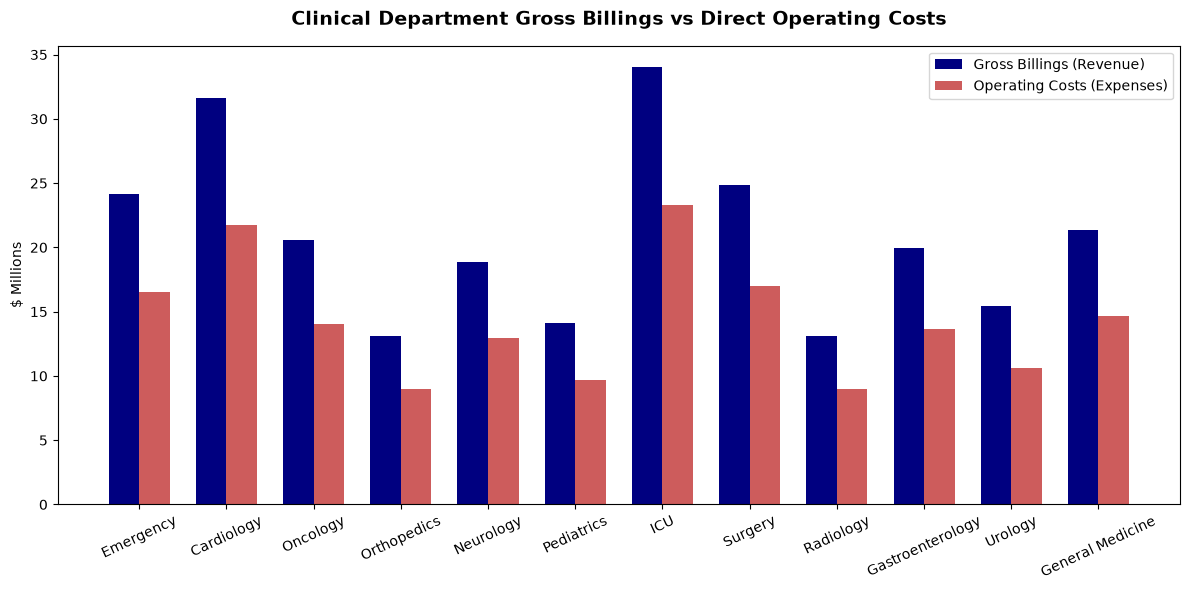

In [3]:
dept_financials = df.groupby('department_id')[['charge_amount', 'cost_amount', 'net_profit']].sum().reset_index()
# Map department names
depts = pd.read_csv(data_dir / 'departments.csv')
dept_financials = dept_financials.merge(depts, on='department_id')

plt.figure(figsize=(12, 6))
x = np.arange(len(dept_financials))
width = 0.35

plt.bar(x - width/2, dept_financials['charge_amount'] / 1e6, width, label='Gross Billings (Revenue)', color='navy')
plt.bar(x + width/2, dept_financials['cost_amount'] / 1e6, width, label='Operating Costs (Expenses)', color='indianred')

plt.xticks(x, dept_financials['department'], rotation=25)
plt.ylabel('$ Millions')
plt.title('Clinical Department Gross Billings vs Direct Operating Costs', fontsize=14, fontweight='bold', pad=15)
plt.legend()
plt.tight_layout()
plt.savefig(visuals_dir / 'departmental_charge_vs_cost.png', dpi=200)
plt.show()

## 4. Operational Flow Bottlenecks: Triage Wait Times vs Patient Severity
We audit ER wait times against clinical severity. We expect emergency stays to prioritize high-severity patients, but is wait time well-triage-correlated?

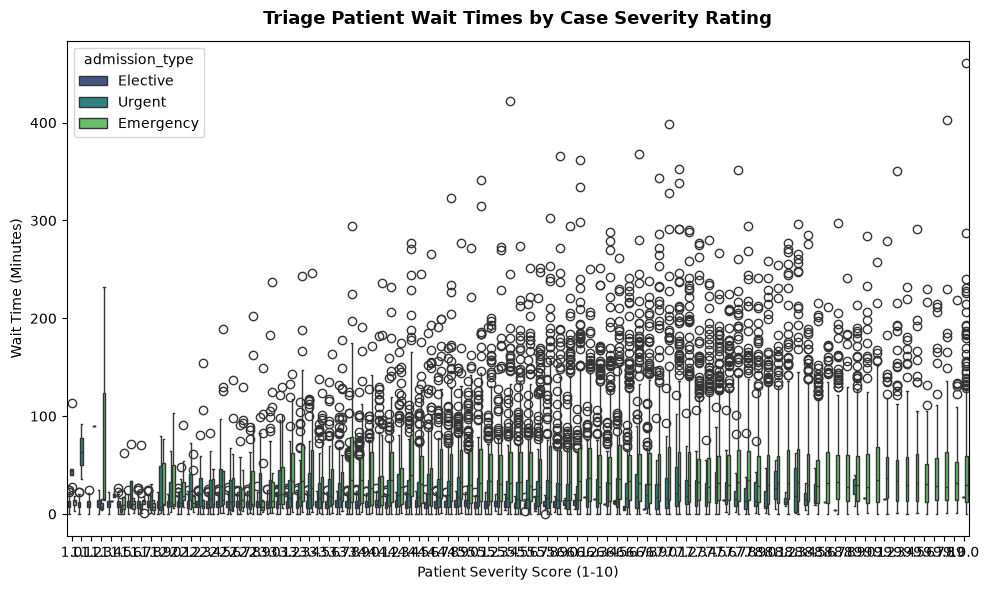

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='severity_score', y='wait_minutes', hue='admission_type', palette='viridis')
plt.title('Triage Patient Wait Times by Case Severity Rating', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Patient Severity Score (1-10)')
plt.ylabel('Wait Time (Minutes)')
plt.tight_layout()
plt.savefig(visuals_dir / 'wait_time_vs_severity.png', dpi=200)
plt.show()

## 5. Patient Experience violin distribution
We visualize satisfaction scores by clinical service line to pinpoint quality gaps.

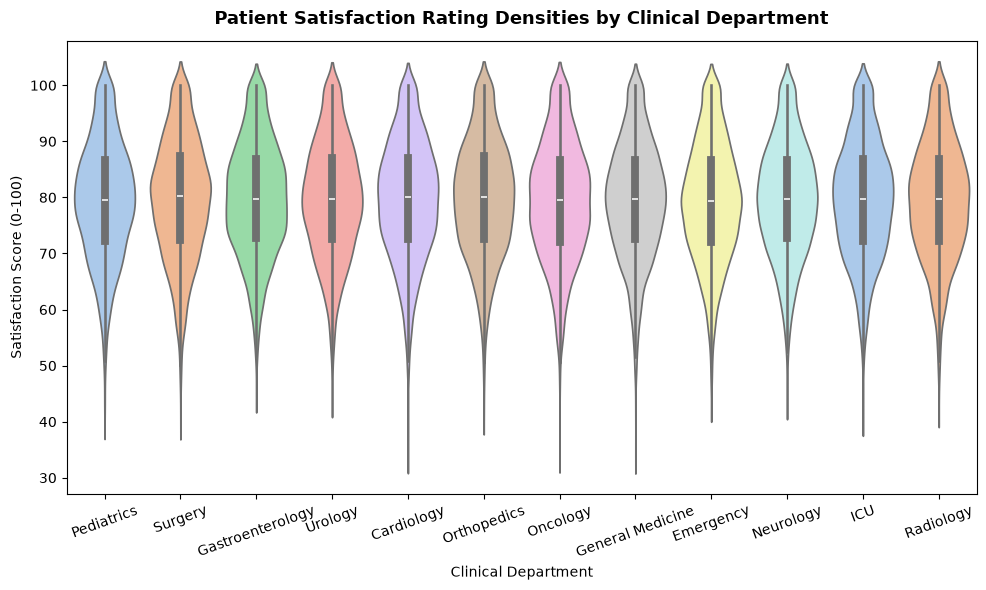

In [5]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df.merge(depts, on='department_id'), x='department', y='satisfaction_score', palette='pastel', hue='department', legend=False)
plt.title('Patient Satisfaction Rating Densities by Clinical Department', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Clinical Department')
plt.ylabel('Satisfaction Score (0-100)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(visuals_dir / 'patient_satisfaction_densities.png', dpi=200)
plt.show()

## 6. Interactive Multi-Axis Exploration
For the local HTML preview dashboard, we export interactive Plotly charts mapping Length of Stay vs Satisfaction grouped by admission type.

In [6]:
fig = px.scatter(
    df.sample(min(1000, len(df))), 
    x='length_of_stay', 
    y='satisfaction_score', 
    color='admission_type', 
    size='charge_amount', 
    hover_data=['patient_age'],
    title='Patient Length of Stay vs Satisfaction (Sampled Inpatients)'
)
fig.write_html(PROJECT_ROOT / 'dashboards' / 'python_dashboard.html')
print("Interactive Plotly master chart written to dashboards/python_dashboard.html.")

Interactive Plotly master chart written to dashboards/python_dashboard.html.
